In [35]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib
from matplotlib import patches
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

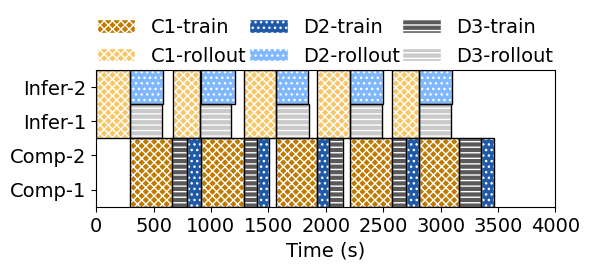

In [36]:
def parse_phase_time(file: str, job_name: str, log_type='sched'):
    with open(file, 'r') as f:
        content = f.read().split("\n")
    ts = {phase: [] for phase in ['generate', 'train']}
    te = {phase: [] for phase in ['generate', 'train']}
    for line in content:
        for phase in ['generate', 'train']:
            pattern_start = f"Event(job={job_name}, phase={phase}, type=status, value=running"
            pattern_end = f"Event(job={job_name}, phase={phase}, type=done"
            if pattern_start in line:
                t = datetime.strptime(line.split(" |")[0], '%Y/%m/%d %H:%M:%S') if log_type == "sched" else datetime.strptime(line[:len("[2025-10-10 15:57:12]")], '[%Y-%m-%d %H:%M:%S]')
                ts[phase].append(t)
            if pattern_end in line:
                t = datetime.strptime(line.split(" |")[0], '%Y/%m/%d %H:%M:%S') if log_type == "sched" else datetime.strptime(line[:len("[2025-10-10 15:57:12]")], '[%Y-%m-%d %H:%M:%S]')
                te[phase].append(t)
    return ts, te

fig = plt.figure(figsize=(6, 2.5))
ax = plt.gca()
tmin = None
for jobid in range(1, 4):
    ts, te = parse_phase_time('case5.out', f'job{jobid}')
    if tmin is None or ts['generate'][0] < tmin:
        tmin = ts['generate'][0]

patterns = {
    "job1": {"generate": ("#F6C667", "XXXX"), "train": ("#C07A00", "XXXX")},
    "job2": {"generate": ("#7FB8FF", '...'), "train": ("#1E5AA8", '...')},
    "job3": {"generate": ("#C9C9C9", '---'), "train": ("#595959", '---')}
}
for jobid in range(1, 4):
    job_name = f'job{jobid}'
    ts, te = parse_phase_time('case5.out', job_name)
    for i in range(min(len(ts['train']), len(te['train']))):
        x = (ts['train'][i] - tmin).total_seconds()
        ax.add_patch(patches.Rectangle([x, 0], (te['train'][i] - ts['train'][i]).total_seconds(), 2, edgecolor='white', hatch=patterns[job_name]['train'][1], facecolor=patterns[job_name]['train'][0], zorder=1))
        ax.add_patch(patches.Rectangle([x, 0], (te['train'][i] - ts['train'][i]).total_seconds(), 2, edgecolor='black', facecolor='none', zorder=2))
    for i in range(min(len(ts['generate']), len(te['generate']))):
        x = (ts['generate'][i] - tmin).total_seconds()
        if jobid == 1:
            ax.add_patch(patches.Rectangle([x, 2], (te['generate'][i] - ts['generate'][i]).total_seconds(), 2, edgecolor='white', hatch=patterns[job_name]['generate'][1], facecolor=patterns[job_name]['generate'][0], zorder=1))
            ax.add_patch(patches.Rectangle([x, 2], (te['generate'][i] - ts['generate'][i]).total_seconds(), 2, edgecolor='black', facecolor='none', zorder=2))
        else:
            ax.add_patch(patches.Rectangle([x, 5 - jobid], (te['generate'][i] - ts['generate'][i]).total_seconds(), 1, edgecolor='white', hatch=patterns[job_name]['generate'][1], facecolor=patterns[job_name]['generate'][0], zorder=1))
            ax.add_patch(patches.Rectangle([x, 5 - jobid], (te['generate'][i] - ts['generate'][i]).total_seconds(), 1, edgecolor='black', facecolor='none', zorder=2))
        jtype = 'D' if jobid != 1 else 'C'
    ax.add_patch(patches.Rectangle([0, 0], 0, 0, edgecolor='white', hatch=patterns[job_name]['train'][1], facecolor=patterns[job_name]['train'][0], zorder=1, label=f"{jtype}{jobid}-train" ))
    ax.add_patch(patches.Rectangle([0, 0], 0, 0, edgecolor='white', hatch=patterns[job_name]['generate'][1], facecolor=patterns[job_name]['generate'][0], zorder=1, label=f"{jtype}{jobid}-rollout"))
plt.xlim(0, 4000)
plt.ylim(0, 4)
plt.yticks([0.5, 1.5, 2.5, 3.5], ["Comp-1", "Comp-2", "Infer-1", "Infer-2"], fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
lgd = plt.figlegend(ncols=3, loc='upper center', bbox_to_anchor=(0.55, 1.1), fontsize=14, columnspacing=0.1, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("case5.pdf", bbox_extra_artists=(lgd,), bbox_inches='tight')